# Logistic Regression using oops and sklearn from scratch



In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [104]:
class LogisticRegression:

  def __init__(self, learning_rate=0.01, epochs=1000):

    self.learning_rate = learning_rate
    self.epochs = epochs

    self.weights = None
    self.bias = None

  def sigmoid(self,z):
    """Compute sigmoid probability."""
    return 1/(1+np.exp(-z))

  def fit(self,X,y):
    n_samples, n_features = X.shape
    # suppose X.shape has (455,30) so n_samples =455 and n_feature = 30

    self.weights = np.zeros(n_features)
    self.bias = 0.0

    self.losses = []

    for epoch in range(self.epochs):

      z = X @ self.weights + self.bias
      # z hsape is n_samples we got one vale for each sample we not compute one at a time we compute all at a time by vectorization

      y_pred = self.sigmoid(z)

      loss = -np.mean(
          y * np.log(y_pred + 1e-15) +
          (1 - y) * np.log(1 - y_pred + 1e-15)
      )

      self.losses.append(loss)

      error = y_pred - y

      # dw = (1/n_samples) * X.T @ error
      # db = (1/n_samples) * np.sum(error)

      dw = (X.T @ error) / n_samples
      db = np.sum(error) / n_samples

      self.weights = self.weights - self.learning_rate * dw
      self.bias = self.bias - self.learning_rate * db




  def predict_proba(self,X):

    return self.sigmoid(X @ self.weights + self.bias)

  def predict(self,X):
    """Predct class labels."""
    probabilities = self.predict_proba(X)
    return (probabilities >= 0.5).astype(int)


  def accuracy(self,y_true,y_pred):
     """Compute accuracy."""
     return np.mean(y_true == y_pred)

  def precision(self,y_true,y_pred):
    """Compute precision."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp)

  def recall(self,y_true,y_pred):
    """Compute recall."""
    tp = np.sum((y_true ==1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn)

  def f1score(self,y_true,y_pred):
    """Compute F1 score."""
    precision = self.precision(y_true,y_pred)
    recall = self.recall(y_true,y_pred)
    return 2 * (precision * recall) / (precision + recall)

  def confusionmatrix(self,y_true,y_pred):
    """Compute confusion matrix."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn,fp],[fn,tp]])


# Using sklearn load dataset


In [105]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target


In [106]:
# model slection didviding data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [107]:
# feature scalling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [108]:
# Create  my own  model
model = LogisticRegression(learning_rate=0.01,epochs =1000)

In [109]:
model.fit(X_train, y_train)

In [110]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [111]:
print(y_pred[:10])
print(y_test[:10])

[1 0 0 1 1 0 0 0 0 1]
[1 0 0 1 1 0 0 0 1 1]


In [112]:
accur  = model.accuracy(y_test,y_pred)
accur

np.float64(0.9824561403508771)

In [113]:
# sklearn model

from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression()
sk_model.fit(X_train,y_train)

LogisticRegression()

In [114]:
sk_y_pred = sk_model.predict(X_test)

In [115]:
print("Our Model:", y_pred[:10])
print("Sklearn  :", sk_y_pred[:10])
print("Actual   :", y_test[:10])

Our Model: [1 0 0 1 1 0 0 0 0 1]
Sklearn  : [1 0 0 1 1 0 0 0 1 1]
Actual   : [1 0 0 1 1 0 0 0 1 1]


In [116]:
from sklearn.metrics import accuracy_score

our_accuracy = accuracy_score(y_test,y_pred)
sklearn_accuracy = accuracy_score(y_test,sk_y_pred)

In [117]:
print("our Accuracy", our_accuracy)
print("sklearn Accuracy", sklearn_accuracy)

our Accuracy 0.9824561403508771
sklearn Accuracy 0.9736842105263158


# Sklearn metrics

In [118]:
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [119]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[42  1]
 [ 1 70]]


In [120]:
accuracy_skmodel = accuracy_score(y_test,y_pred)
print(accuracy_skmodel)


precision = precision_score(y_test,y_pred)
print(precision)


recall = recall_score(y_test,y_pred)
print(recall)

f1score = f1_score(y_test,y_pred)
print(f1score)

classifireport = classification_report(y_test,y_pred)
print(classifireport)

0.9824561403508771
0.9859154929577465
0.9859154929577465
0.9859154929577465
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# My model metrics evaluation

In [121]:
print(model.confusionmatrix(y_test, y_pred))
print("Accuracy :", model.accuracy(y_test, y_pred))
print("Precision:", model.precision(y_test, y_pred))
print("Recall   :", model.recall(y_test, y_pred))
print("F1 Score :", model.f1score(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[42  1]
 [ 1 70]]
Accuracy : 0.9824561403508771
Precision: 0.9859154929577465
Recall   : 0.9859154929577465
F1 Score : 0.9859154929577465
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# SK learn model metrics evaluation

In [122]:
print(confusion_matrix(y_test, sk_y_pred))
print("Accuracy :", accuracy_score(y_test, sk_y_pred))
print("Precision:", precision_score(y_test, sk_y_pred))
print("Recall   :", recall_score(y_test, sk_y_pred))
print("F1 Score :", f1_score(y_test, sk_y_pred))

print(classification_report(y_test, sk_y_pred))

[[41  2]
 [ 1 70]]
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



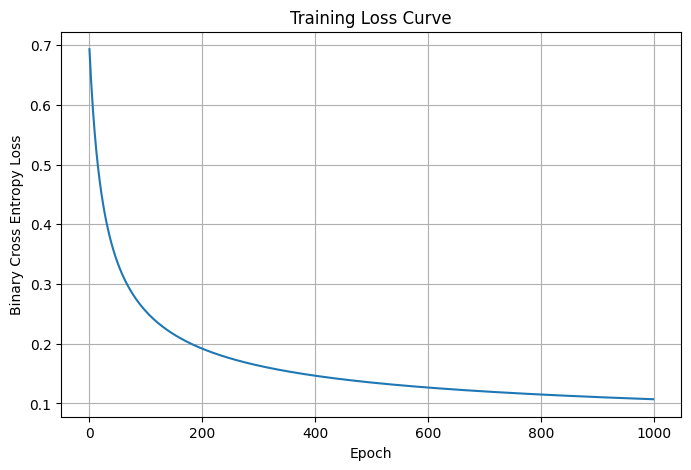

In [131]:
plt.figure(figsize=(8,5))
plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

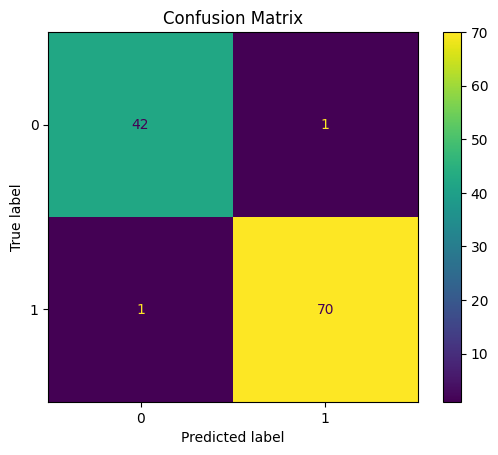

In [126]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

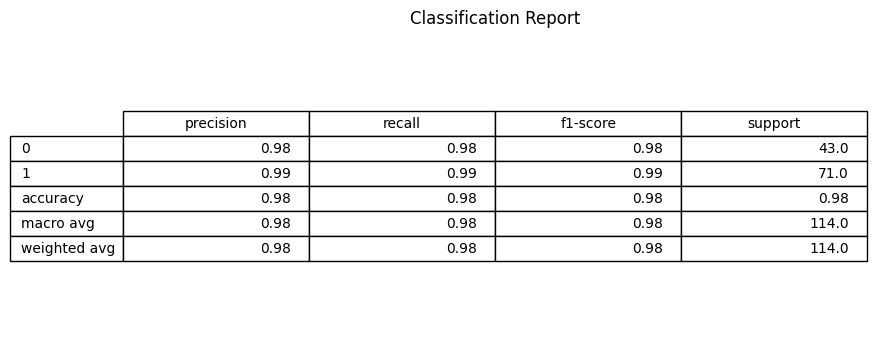

In [128]:
# Classification report image

report = classification_report(y_test, y_pred, output_dict=True)

df = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(8,4))
ax.axis("off")

table = ax.table(
    cellText=df.round(2).values,
    rowLabels=df.index,
    colLabels=df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Classification Report")
plt.savefig("classification_report.png", dpi=300, bbox_inches="tight")
plt.show()